# Contour Chart

A contour chart shows a surface over two continuous variables, such as the elevation of a landscape, the loss of a model over two parameters, or the density of scattered points, through lines of equal value (or the bands between them). The lines answer *where are the peaks and the valleys, and how steep is the way between them*. This guide shows how to create contour charts with the [datachart.charts.ContourChart](../../../references/charts/contourchart/#datachart.charts.ContourChart) function, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-contour-chart), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import ContourChart

## Basics

The examples in this guide share one surface: an illustrative hill, 10 km from west to east and 8 km from south to north, the way a hiking map would show it. It has two peaks, a higher West Peak (1738 m) and a lower East Peak (1386 m), joined by a saddle (the lowest point of the ridge between them, 1075 m), and the valley floor rises gently to the north. The values come from a formula (two smooth bumps on a tilted plane), defined in a hidden cell. `terrain` holds the surface: `x` is the distance east in km, `y` the distance north in km, and `z` the elevation in m, one row per `y` value and one column per `x` value. `WEST_PEAK`, `EAST_PEAK` and `SADDLE` hold the (east, north) position of the three landmarks.

In [2]:
import numpy as np

# an illustrative hill: two smooth peaks on a valley floor that rises to the north
EAST_KM = np.linspace(0, 10, 101)
NORTH_KM = np.linspace(0, 8, 81)
E, N = np.meshgrid(EAST_KM, NORTH_KM)


def bump(east, north, height, spread_east, spread_north):
    return height * np.exp(-((E - east) ** 2 / (2 * spread_east**2) + (N - north) ** 2 / (2 * spread_north**2)))


ELEVATION = 350 + 25 * N + bump(3.2, 5.0, 1250, 1.3, 1.1) + bump(7.0, 3.2, 950, 1.4, 1.6)
terrain = {"x": EAST_KM.tolist(), "y": NORTH_KM.tolist(), "z": ELEVATION.round().tolist()}

# (east, north) in km of the landmarks
WEST_PEAK = (3.2, 5.0)  # 1738 m
EAST_PEAK = (7.0, 3.3)  # 1386 m
SADDLE = (5.3, 4.0)  # 1075 m

The data is one dictionary. `z` is a list of rows, so its length matches `y` and the length of each row matches `x`:

In [3]:
len(terrain["x"]), len(terrain["y"]), len(terrain["z"]), len(terrain["z"][0])

(101, 81, 81, 101)

**Basic example.** Only the `data` argument is required. The surface is cut at a handful of round elevations and each cut is drawn as an iso-line, a line of equal value like the elevation lines of a map. The small closed loops mark the two peaks; the line that wraps around both of them passes just below the saddle:

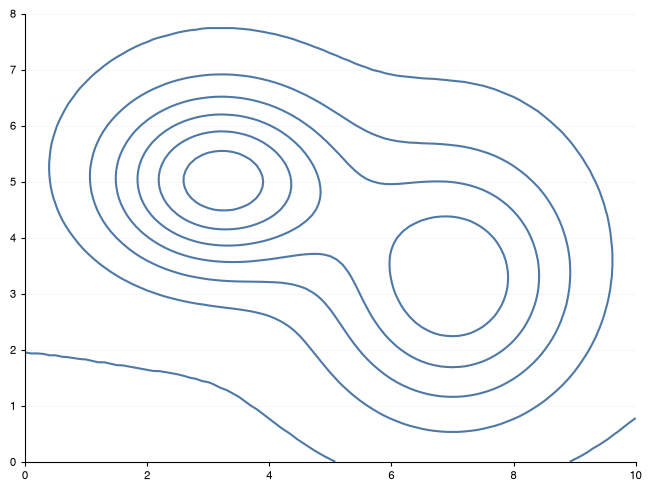

In [4]:
ContourChart(
    # add the data to the chart
    data=terrain
).show()

## Customizing the Contour Chart

Every customization is either a keyword argument of `ContourChart` or a `plot_contour_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title and axis labels                 | `title`, `xlabel`, `ylabel`                                             | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| set or format the ticks                     | `xticks`, `yticks`, `xticks_format`, `yticks_format`                    | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| resize the figure                           | `figsize`                                                               | [Figure size, grid and aspect ratio](#figure-size-grid-and-aspect-ratio) |
| show grid lines                             | `show_grid`                                                             | [Figure size, grid and aspect ratio](#figure-size-grid-and-aspect-ratio) |
| keep one unit equal on both axes            | `aspect_ratio`                                                          | [Figure size, grid and aspect ratio](#figure-size-grid-and-aspect-ratio) |
| fill the bands between the levels           | `filled`                                                                | [Filled contours and colorbar](#filled-contours-and-colorbar) |
| add and caption a colorbar                  | `show_colorbars`, `colorbar`                                            | [Filled contours and colorbar](#filled-contours-and-colorbar) |
| write the level values on the lines         | `show_labels`, `valfmt`                                                 | [Inline labels](#inline-labels) |
| choose the values that cut the surface      | `levels`                                                                | [Levels](#levels) |
| change the line color, width, or style      | `style={"plot_contour_color": ..., "plot_contour_line_width": ...}`     | [Contour style](#contour-style) |
| color the lines or bands with a colormap    | `style={"plot_contour_cmap": ...}`                                      | [Contour style](#contour-style) |
| pin or rescale the colormap range           | `vmin`, `vmax`, `norm`                                                  | [Normalization](#normalization) |
| mark a position or shade a region           | `vlines`, `hlines`, `dlines`, `vspans`, `hspans`                      | [Reference lines and bands](#reference-lines-and-bands) |
| put a note on the chart                     | `texts`                                                                 | [Text annotations](#text-annotations) |
| overlay several surfaces                    | `data` as a list, `subtitle`, `show_legend`                             | [Multiple Contour Charts](#multiple-contour-charts) |
| title and place the legend                  | `legend`                                                                | [Legend](#legend) |
| highlight one surface, mute the rest        | `emphasis`, `emphasis_rule`                                             | [Emphasis](#emphasis) |
| draw each surface in its own subplot        | `subplots`, `max_cols`, `sharex`, `sharey`                              | [Subplots and shared axes](#subplots-and-shared-axes) |
| draw a path or points over a surface        | `Panel`, `Grid`                                                         | [Composing with Panel and Grid](#composing-with-panel-and-grid) |
| draw the density of scattered points        | `stats.kde2d`, `bandwidth`                                              | [Density of scattered points](#density-of-scattered-points) |
| use a logarithmic axis                      | `scalex`, `scaley`                                                      | [Axis scales](#axis-scales) |
| draw a surface over time                    | temporal `x` values, `xticks_format`                                    | [Datetime axis](#datetime-axis) |
| save the chart to a file                    | `save_figure`                                                           | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `levels` | [`CONTOUR_LEVELS`](../../../references/constants/#datachart.constants.CONTOUR_LEVELS) |
| `emphasis` | [`EMPHASIS`](../../../references/constants/#datachart.constants.EMPHASIS) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `aspect_ratio` | [`ASPECT_RATIO`](../../../references/constants/#datachart.constants.ASPECT_RATIO) |
| `scalex` | [`SCALE`](../../../references/constants/#datachart.constants.SCALE) |
| `scaley` | [`SCALE`](../../../references/constants/#datachart.constants.SCALE) |
| `norm` | [`NORMALIZE`](../../../references/constants/#datachart.constants.NORMALIZE) |
| `valfmt` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `xticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |
| `yticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |
| `colorbar={"location": ..., "format": ..., "orientation": ...}` | [`COLORBAR_LOCATION`](../../../references/constants/#datachart.constants.COLORBAR_LOCATION), [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`ORIENTATION`](../../../references/constants/#datachart.constants.ORIENTATION) |

The full list of style attributes is in the [datachart.typings.ContourStyleAttrs](../../../references/charts/contourchart/#datachart.typings.ContourStyleAttrs) type; the full list of parameters is in the [datachart.charts.ContourChart](../../../references/charts/contourchart/#datachart.charts.ContourChart) reference.

### Title, axis labels and ticks

A contour chart without axis labels leaves the reader guessing what the axes and the lines measure; `title`, `xlabel` and `ylabel` say it. `xticks` and `yticks` place the ticks, here one every 2 km, and `xticks_format` and `yticks_format` format them: a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) member or any `"{x:.1f}"` style string, so the unit can travel with the numbers. `xtickrotate` and `ytickrotate` tilt the labels when they crowd, and `xmin`, `xmax`, `ymin` and `ymax` crop the view; this map needs neither.

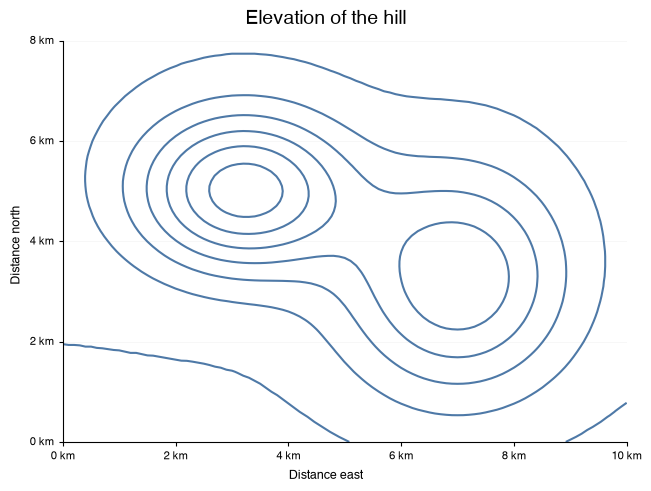

In [5]:
ContourChart(
    data=terrain,
    # add the title
    title="Elevation of the hill",
    # add the x and y axis labels
    xlabel="Distance east",
    ylabel="Distance north",
    # one tick every 2 km, with the unit
    xticks=[0, 2, 4, 6, 8, 10],
    yticks=[0, 2, 4, 6, 8],
    xticks_format="{x:.0f} km",
    yticks_format="{x:.0f} km",
).show()

### Figure size, grid and aspect ratio

`figsize` takes a `(width, height)` tuple in inches or one of the presets in [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE), sized for a full or half page width. `show_grid` draws grid lines ([SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID)); on a map they help read a position off an iso-line, so both axes get them.

A map has the same unit on both axes, and a stretched map misrepresents the shape of the land: by default the axes fill the figure, so 1 km east and 1 km north are drawn at different lengths. `aspect_ratio=ASPECT_RATIO.EQUAL` ([ASPECT_RATIO](../../../references/constants/#datachart.constants.ASPECT_RATIO)) draws them at the same length, and the slopes keep their true shape. Keep the default `ASPECT_RATIO.AUTO` when the two axes measure different things.

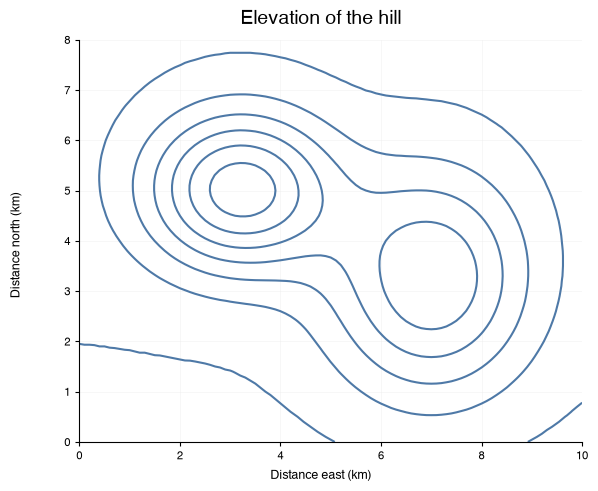

In [6]:
from datachart.constants import ASPECT_RATIO, FIG_SIZE, SHOW_GRID

ContourChart(
    data=terrain,
    title="Elevation of the hill",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    # a full-width figure
    figsize=FIG_SIZE.FULL_MEDIUM,
    # grid lines on both axes
    show_grid=SHOW_GRID.BOTH,
    # 1 km is the same length on both axes
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

### Filled contours and colorbar

Iso-lines show the shape of the surface, but the eye has to count lines to tell high from low. `filled=True` colors the bands between the levels by their value instead (with the heatmap colormap by default), so the high ground reads at a glance; grid lines are off by default, as the bands would cover them. `show_colorbars=True` adds a colorbar that maps the shades back to values, and `colorbar` configures it ([ColorbarSettingAttrs](../../../references/typings/#datachart.typings.ColorbarSettingAttrs)): `label` names the quantity, `location` places it with a [COLORBAR_LOCATION](../../../references/constants/#datachart.constants.COLORBAR_LOCATION) member, `format` formats its ticks and `ticks` places them. An `orientation` ([ORIENTATION](../../../references/constants/#datachart.constants.ORIENTATION)) on its own also works.

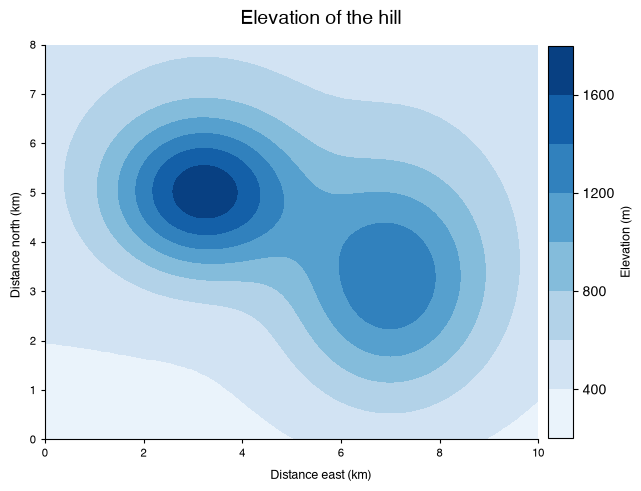

In [7]:
from datachart.constants import COLORBAR_LOCATION

ContourChart(
    data=terrain,
    # fill the bands between the levels
    filled=True,
    # a captioned colorbar on the right, one tick every 400 m
    show_colorbars=True,
    colorbar={
        "label": "Elevation (m)",
        "location": COLORBAR_LOCATION.RIGHT,
        "format": "{x:.0f}",
        "ticks": [400, 800, 1200, 1600],
    },
    title="Elevation of the hill",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

### Inline labels

A reader of a map wants the elevation of a line without looking it up. `show_labels=True` writes the value of each level along its iso-line, and `valfmt` formats it: a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) member or any `"{x:.1f}"` style string with the value named `x`. The labels take the line color and a font smaller than the general font; the `plot_contour_label_font_size` and `plot_contour_label_font_color` style attributes change them (see [Contour style](#contour-style)).

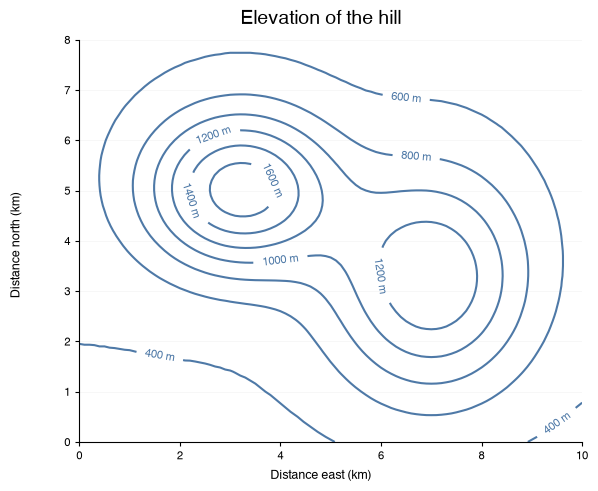

In [8]:
ContourChart(
    data=terrain,
    # write the elevation along each line, with its unit
    show_labels=True,
    valfmt="{x:.0f} m",
    title="Elevation of the hill",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

### Levels

The levels decide what a contour chart can show: a feature that falls between two levels is invisible. `levels` takes one of the following:

| Value | Description |
| :---- | :---------- |
| `CONTOUR_LEVELS.AUTO` | Matplotlib's own choice: about eight round values across the range of the surface (the default). |
| `CONTOUR_LEVELS.RICE` | The Rice rule: `2 * n ** (1/3)` levels, where `n` is the number of grid points along an axis. |
| `CONTOUR_LEVELS.FD` | The Freedman-Diaconis rule: the value range over `2 * IQR * n ** (-1/3)`, usually denser than Rice. |
| an integer | A target number of levels, snapped to round values. |
| a list | The exact level values to draw. |

The rules live in [datachart.constants.CONTOUR_LEVELS](../../../references/constants/#datachart.constants.CONTOUR_LEVELS). They follow the grid resolution rather than the surface, so they are opt-ins. An integer is the quick way to ask for more detail: twenty levels show the gentle rise of the valley floor that the default hides.

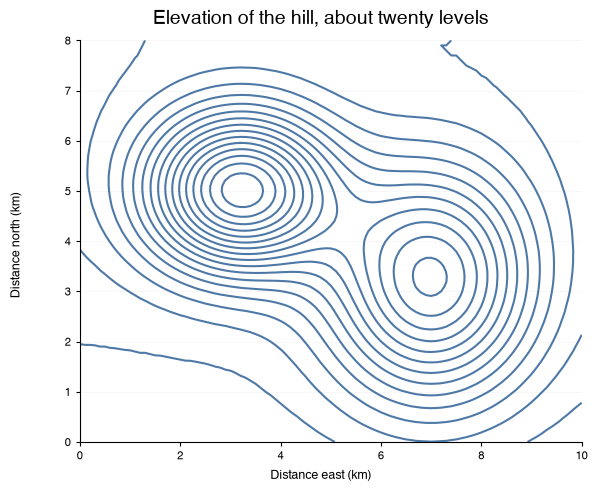

In [9]:
from datachart.constants import CONTOUR_LEVELS

ContourChart(
    data=terrain,
    # about twenty round levels
    levels=20,
    title="Elevation of the hill, about twenty levels",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

An explicit list says exactly which elevations matter. The saddle sits at 1075 m, so a level at 1000 m still wraps around both peaks as one ridge, while a level at 1150 m splits into two separate hills. Levels every 150 m from 700 m, which include both (plus one at 400 m for the valley floor), put the saddle between two lines where the reader can find it; `SADDLE_LEVELS` keeps the list for the charts below:

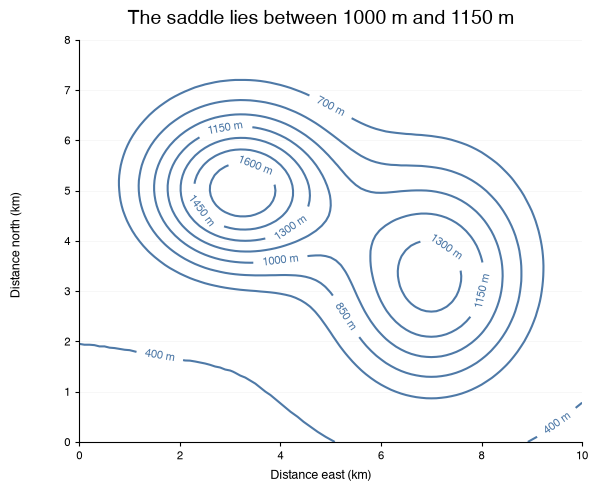

In [10]:
# 1000 m wraps both peaks, 1150 m splits them
SADDLE_LEVELS = [400, 700, 850, 1000, 1150, 1300, 1450, 1600]

ContourChart(
    data=terrain,
    levels=SADDLE_LEVELS,
    show_labels=True,
    valfmt="{x:.0f} m",
    title="The saddle lies between 1000 m and 1150 m",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

The rules are handy when the surface is unfamiliar and the right spacing is not obvious. On this 101 by 81 grid the Rice rule gives about ten levels:

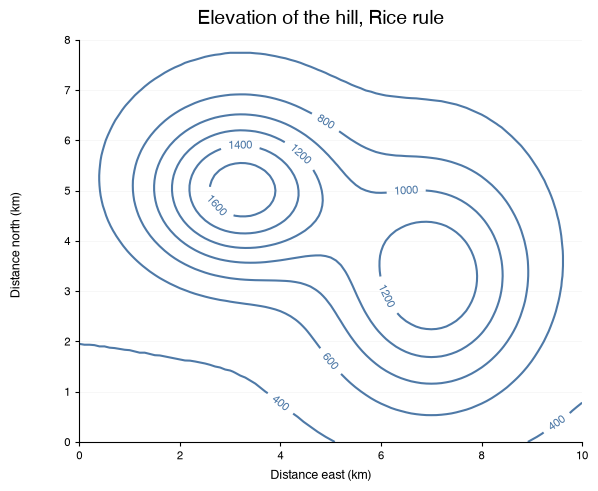

In [11]:
ContourChart(
    data=terrain,
    # the number of levels follows the grid resolution
    levels=CONTOUR_LEVELS.RICE,
    show_labels=True,
    valfmt="{x:.0f}",
    title="Elevation of the hill, Rice rule",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

### Contour style

The `style` dictionary sets the look of the contour: the line color, width and style, the colormap, the alpha, the z-order among other layers, and the font of the inline labels. The attributes are listed in [datachart.typings.ContourStyleAttrs](../../../references/charts/contourchart/#datachart.typings.ContourStyleAttrs), and any attribute left out keeps the value of the active theme. A topographic map traditionally draws its elevation lines thin and brown, with the labels in the same color; the line styles are in [LINE_STYLE](../../../references/constants/#datachart.constants.LINE_STYLE).

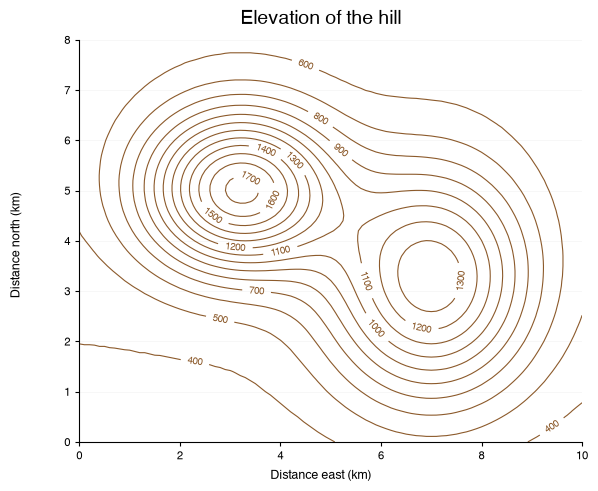

In [12]:
from datachart.constants import LINE_STYLE

ContourChart(
    data=terrain,
    # thin brown lines, as on a topographic map
    style={
        "plot_contour_color": "#8c5a2b",
        "plot_contour_line_width": 0.8,
        "plot_contour_line_style": LINE_STYLE.SOLID,
        "plot_contour_label_font_size": 7,
        "plot_contour_label_font_color": "#8c5a2b",
    },
    levels=list(range(400, 1800, 100)),
    show_labels=True,
    valfmt="{x:.0f}",
    title="Elevation of the hill",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

With `plot_contour_cmap` set, iso-lines are colored by their level instead of in one color, which tells low from high without filling the chart. The colormap is a name from [COLORS](../../../references/constants/#datachart.constants.COLORS) or a list of colors; lines are colored from its darker part, since the lightest shades would vanish on a white background. For filled contours it sets the colors of the bands, and a colormap from a green valley to brown summits reads like terrain:

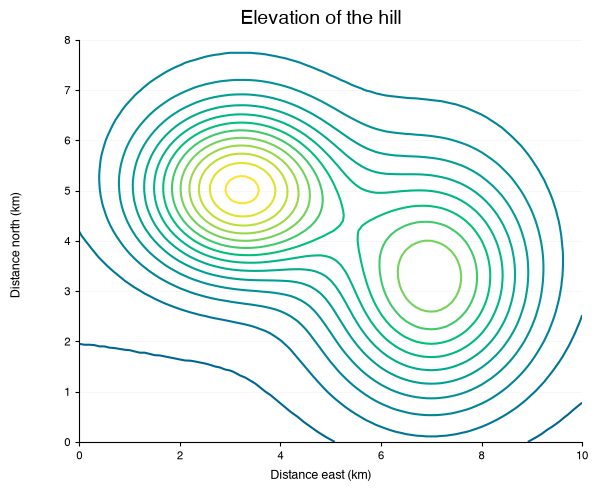

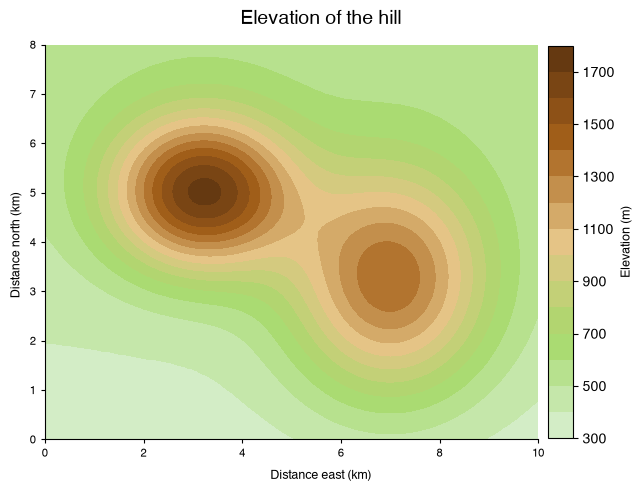

In [13]:
from datachart.constants import COLORS

ContourChart(
    data=terrain,
    # color each line by its elevation
    style={"plot_contour_cmap": COLORS.Viridis},
    levels=list(range(400, 1800, 100)),
    title="Elevation of the hill",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

TERRAIN_COLORS = ["#d9f0d3", "#a6d96a", "#e6c587", "#a6611a", "#5c3310"]

ContourChart(
    data=terrain,
    filled=True,
    show_colorbars=True,
    colorbar={"label": "Elevation (m)"},
    # a custom colormap, from a green valley to brown summits
    style={"plot_contour_cmap": TERRAIN_COLORS},
    levels=list(range(300, 1900, 100)),
    title="Elevation of the hill",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

### Normalization

The colors of a filled contour come from two steps: each level is normalized to the 0 to 1 range, then picks its color from the colormap. By default the lowest level gets the first color and the highest the last, so two maps of different hills each use the full colormap, and the same shade means different elevations on each. `vmin` and `vmax` pin the range instead. Pinned to the 0 to 3000 m of a mountain region, the same hill looks as modest as it is:

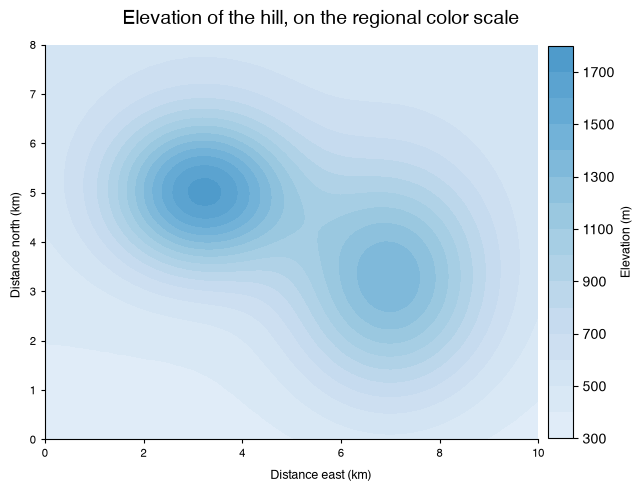

In [14]:
ContourChart(
    data=terrain,
    filled=True,
    show_colorbars=True,
    colorbar={"label": "Elevation (m)"},
    levels=list(range(300, 1900, 100)),
    # the color range of the whole region, not of this hill
    vmin=0,
    vmax=3000,
    title="Elevation of the hill, on the regional color scale",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

`norm` changes how the values spread over the 0 to 1 range, with a [NORMALIZE](../../../references/constants/#datachart.constants.NORMALIZE) member (`LINEAR`, `LOG`, `SYMLOG`, `ASINH`, `LOGIT`), and a surface that spans orders of magnitude needs it. `sighting_density`, computed in a hidden cell, is the density of illustrative chamois sightings on the hill, in sightings per km² (the [Multiple Contour Charts](#multiple-contour-charts) section introduces the data). The sightings cluster in a few places, and the density falls a thousandfold towards the edges of the map. With log-spaced levels and `NORMALIZE.LOG`, every tenfold step gets an equally distinct shade, where a linear normalization would spend the colormap on the busy centers and paint the faint outskirts all one color.

In [15]:
from datachart.utils.stats import kde2d

# illustrative GPS sightings of chamois on the hill, by season: (count, center east, center north, spread) per group
rng = np.random.RandomState(42)
SEASONS = ["Summer", "Autumn", "Winter"]
GROUPS = {
    "Summer": [(70, 3.3, 5.3, 0.45)],
    "Autumn": [(40, 3.4, 5.4, 0.55), (35, 7.0, 3.0, 0.5)],
    "Winter": [(55, 5.8, 2.4, 0.7)],
}
sightings = {
    season: [
        {"x": round(float(east), 2), "y": round(float(north), 2)}
        for count, east0, north0, spread in groups
        for east, north in zip(rng.normal(east0, spread, count), rng.normal(north0, spread, count))
    ]
    for season, groups in GROUPS.items()
}


def density(points):
    # sightings per km², on the map extent so the surfaces line up
    surface = kde2d([p["x"] for p in points], [p["y"] for p in points], gridsize=80, xlim=(0, 10), ylim=(0, 8))
    surface["z"] = (np.array(surface["z"]) * len(points)).tolist()
    return surface


season_density = [density(sightings[season]) for season in SEASONS]
sighting_density = density([p for season in SEASONS for p in sightings[season]])

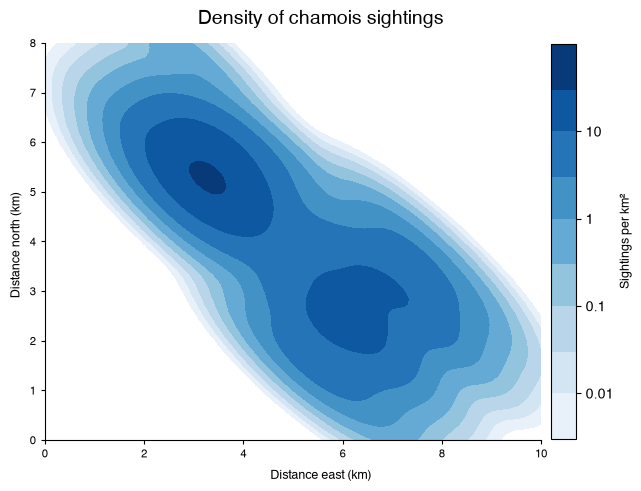

In [16]:
from datachart.constants import NORMALIZE

ContourChart(
    data=sighting_density,
    filled=True,
    show_colorbars=True,
    colorbar={"label": "Sightings per km²", "ticks": [0.01, 0.1, 1, 10], "format": "{x:g}"},
    # log-spaced levels, one shade per step
    levels=[0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
    norm=NORMALIZE.LOG,
    title="Density of chamois sightings",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

### Reference lines and bands

Reference lines and bands put the surface in context. `vlines` and `hlines` draw a line at an x or a y position, and a pair of them crosses at a point, here the saddle, the natural pass between the peaks. `vspans` and `hspans` shade a range of x or y, here the nature reserve that covers the land north of 6 km. Each takes a dictionary or a list of them, with the position, an optional `label` for the legend and a `style`; the keys are listed in [VLineSettingAttrs](../../../references/typings/#datachart.typings.VLineSettingAttrs), [HLineSettingAttrs](../../../references/typings/#datachart.typings.HLineSettingAttrs), [VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs) and [HSpanSettingAttrs](../../../references/typings/#datachart.typings.HSpanSettingAttrs). The legend goes outside the axes (see [Legend](#legend)), so it covers no part of the map.

`dlines` completes the trio. Where `vlines` fixes an x and `hlines` a y, a diagonal is fixed by a `slope` and an `intercept`, so it runs through the data space instead of across it; `dlines={}` on its own draws the parity line `y = x`. It spans the axes unless `xmin` and `xmax` clip it to a segment, and takes the same optional `label` and `style`; the keys are listed in [DLineSettingAttrs](../../../references/typings/#datachart.typings.DLineSettingAttrs). Both axes of a contour chart are distances, so a diagonal is a transect: a line the terrain is read along. The example runs north-east through the saddle, crossing both summits' slopes.

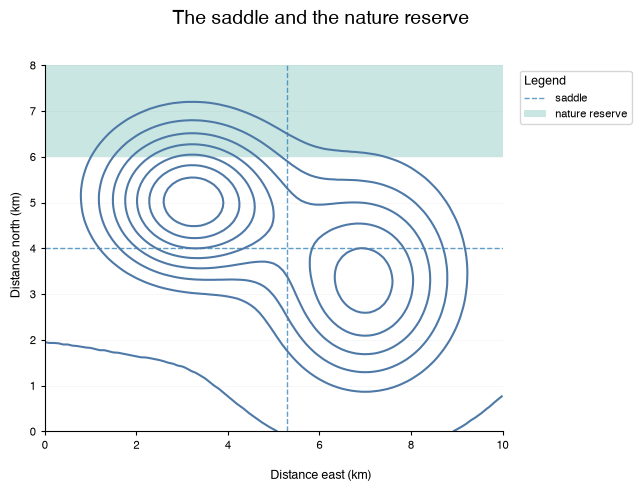

In [17]:
from datachart.constants import LEGEND_LOCATION

ContourChart(
    data=terrain,
    # cross-hairs on the saddle
    vlines={"x": SADDLE[0], "label": "saddle", "style": {"plot_vline_style": LINE_STYLE.DASHED}},
    hlines={"y": SADDLE[1], "style": {"plot_hline_style": LINE_STYLE.DASHED}},
    # the reserve covers everything north of 6 km
    hspans={"ymin": 6, "label": "nature reserve", "style": {"plot_hspan_color": "#2a9d8f"}},
    levels=SADDLE_LEVELS,
    title="The saddle and the nature reserve",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    aspect_ratio=ASPECT_RATIO.EQUAL,
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
).show()

In [ ]:
ContourChart(
    data=terrain,
    # a transect through the saddle, heading north-east
    dlines={
        "slope": 1,
        "intercept": SADDLE[1] - SADDLE[0],
        "label": "north-east transect",
        "style": {"plot_dline_color": "#1d3557", "plot_dline_style": LINE_STYLE.DASHED},
    },
    levels=SADDLE_LEVELS,
    title="A transect through the saddle",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    aspect_ratio=ASPECT_RATIO.EQUAL,
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
).show()

### Text annotations

A map names its landmarks. `texts` places text on the chart, with an optional `target` that draws a connector to a point; the position is in data coordinates by default (here km east and north) or in axes fractions with `"coords": "axes"`. A list places several notes at once. The [Text Annotations](../../utility/annotations/) guide covers placement, connectors and styling.

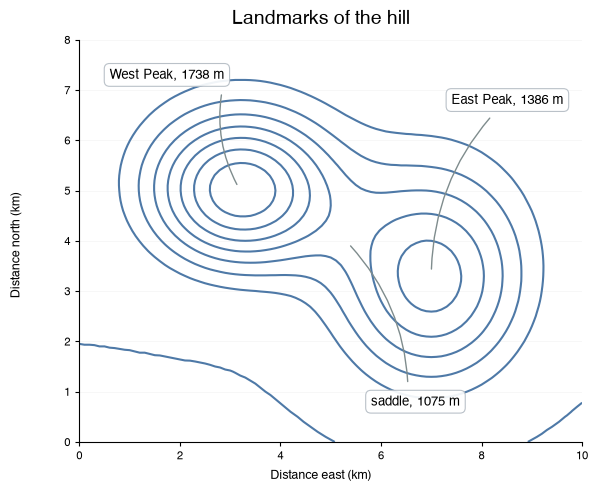

In [18]:
ContourChart(
    data=terrain,
    # one note per landmark, each pointing at it
    texts=[
        {"text": "West Peak, 1738 m", "x": 0.6, "y": 7.3, "target": WEST_PEAK},
        {"text": "East Peak, 1386 m", "x": 7.4, "y": 6.8, "target": EAST_PEAK},
        {"text": "saddle, 1075 m", "x": 5.8, "y": 0.8, "target": SADDLE},
    ],
    levels=SADDLE_LEVELS,
    title="Landmarks of the hill",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

## Multiple Contour Charts

To compare several surfaces on one map, pass a list of them to `data`: each is drawn as its own set of iso-lines in its own color, and the per-chart attributes (`subtitle`, `style`, `emphasis`, `valfmt`, `norm`, `vmin`, `vmax`, `colorbar`) become lists aligned with it. `subtitle` names each surface in the legend that `show_legend` draws. Filled surfaces would cover each other, so fills belong in [subplots](#subplots-and-shared-axes).

The surfaces here come from an illustrative survey of chamois (a mountain goat-antelope) on the hill: `sightings` holds the GPS position of every sighting by season (`SEASONS`), and `season_density` one density surface per season, estimated with [datachart.utils.stats.kde2d](../../../references/utils/stats/#datachart.utils.stats.kde2d) (see [Density of scattered points](#density-of-scattered-points)) on the extent of the map, so the surfaces line up. The story is a seasonal migration: the herd grazes near the West Peak in summer, splits over both peaks in autumn, and moves down to the southern slopes in winter.

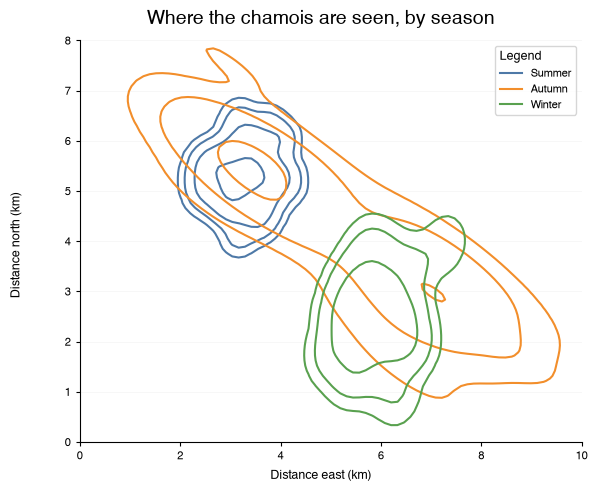

In [19]:
ContourChart(
    # one surface per season
    data=season_density,
    # named for the legend
    subtitle=SEASONS,
    show_legend=True,
    # the same levels on every surface
    levels=[0.5, 2, 8, 32],
    title="Where the chamois are seen, by season",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

### Legend

`show_legend` lists the surfaces; `legend` says where and how, with a `title`, a `location` from [LEGEND_LOCATION](../../../references/constants/#datachart.constants.LEGEND_LOCATION), the number of columns `ncols`, and the `alignment` of the entries from [LEGEND_ALIGN](../../../references/constants/#datachart.constants.LEGEND_ALIGN); a field left out falls back to the theme ([LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs)). Iso-lines can reach any corner of a map, and a legend outside the axes never hides one.

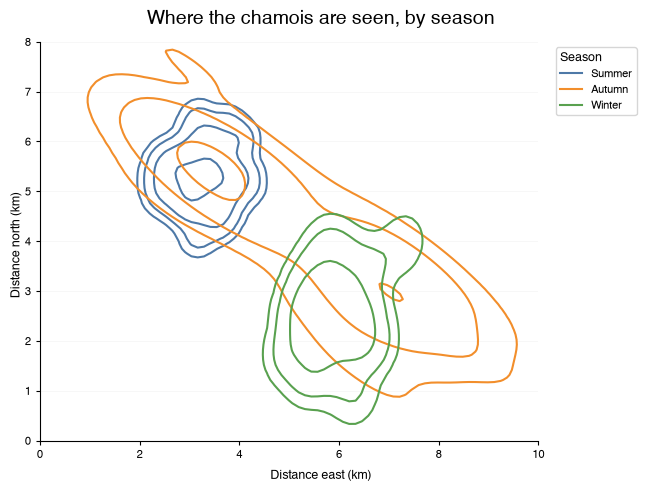

In [20]:
ContourChart(
    data=season_density,
    subtitle=SEASONS,
    show_legend=True,
    # a titled legend outside the axes, to the right
    legend={"title": "Season", "location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    levels=[0.5, 2, 8, 32],
    title="Where the chamois are seen, by season",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

### Emphasis

A chart usually makes one point, and emphasis makes it visible. `emphasis` takes one role per surface, aligned with `data`: `"highlight"` bolds the iso-lines and brings them to the front, `"background"` mutes them into the theme's muted color and drops them from the legend, and `None` leaves them as they are. The roles are also the [EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constants, and the [Highlighting](../../styling/highlighting/) guide covers emphasis across every chart type. Emphasis bolds and mutes lines, so it applies to iso-lines only: with `filled=True` it raises a `ValueError`. Asking where the herd spends the winter turns the other seasons into context:

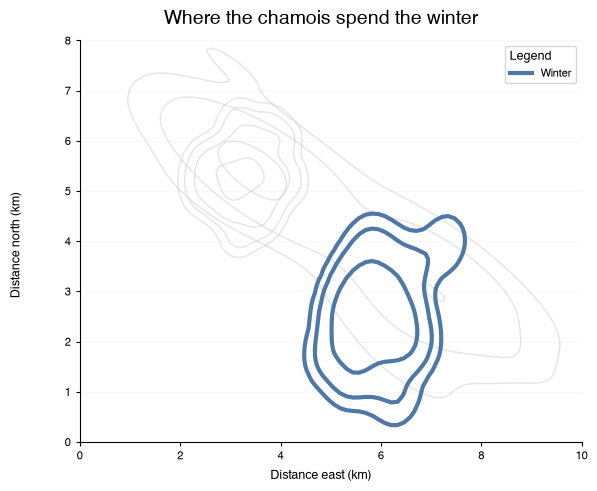

In [21]:
from datachart.constants import EMPHASIS

ContourChart(
    data=season_density,
    subtitle=SEASONS,
    # winter is the question, summer and autumn the context
    emphasis=[EMPHASIS.BACKGROUND, EMPHASIS.BACKGROUND, EMPHASIS.HIGHLIGHT],
    show_legend=True,
    levels=[0.5, 2, 8, 32],
    title="Where the chamois spend the winter",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

`emphasis_rule` picks the surfaces from the data instead. It is a one-key rule, `{"top": n}` or `{"bottom": n}` by rank, `{"above": v}` or `{"below": v}` (strict), or `{"between": (lo, hi)}` (inclusive), read against a summary of each surface's own `z` values: the mean by default, or the `"median"`, `"min"`, `"max"` or `"sum"` named by a `"by"` key. The surfaces that match are highlighted and the rest muted; an explicit `emphasis` role wins over the rule. The season with the highest peak density is the one where the herd is most concentrated:

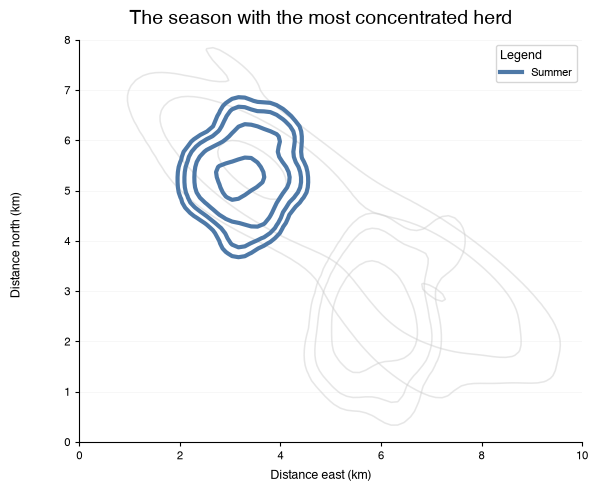

In [22]:
ContourChart(
    data=season_density,
    subtitle=SEASONS,
    # the surface with the highest maximum
    emphasis_rule={"top": 1, "by": "max"},
    show_legend=True,
    levels=[0.5, 2, 8, 32],
    title="The season with the most concentrated herd",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

### Subplots and shared axes

Overlaid iso-lines get busy when the surfaces overlap, and filled surfaces cannot overlap at all. `subplots=True` draws each surface in its own panel: `subtitle` titles the panels, `title`, `xlabel` and `ylabel` stay global, and `max_cols` limits the panels per row. `sharex` and `sharey` put the panels on the same axes, labeled once on the outer panels. One `levels` list for all panels means the same shade is the same density in every season, and the log normalization (see [Normalization](#normalization)) keeps the sparse autumn and winter herds visible next to the dense summer one.

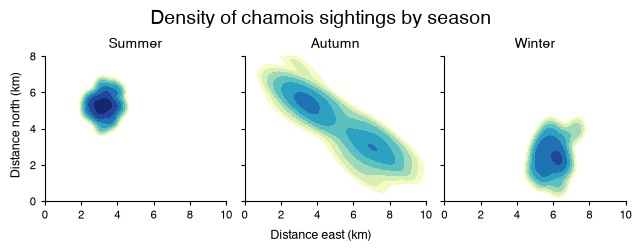

In [23]:
ContourChart(
    data=season_density,
    subtitle=SEASONS,
    # one filled panel per season, side by side
    filled=True,
    subplots=True,
    max_cols=3,
    # the same axes for every season
    sharex=True,
    sharey=True,
    # the same levels, so the shades compare across panels
    levels=[0.25, 0.5, 1, 2, 4, 8, 16, 32, 64],
    norm=NORMALIZE.LOG,
    style={"plot_contour_cmap": COLORS.YlGnBu},
    title="Density of chamois sightings by season",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_SHORT,
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

### Composing with Panel and Grid

A surface is often the background for something else: a path across it, or the points it was estimated from. [Panel](../../../references/utils/#datachart.utils.Panel) overlays figures in one coordinate space. `trail`, defined in a hidden cell, is an illustrative hiking trail from the southwest corner over the saddle to the northeast; a [LineChart](../../../references/charts/linechart/#datachart.charts.LineChart) draws it and a [ScatterChart](../../../references/charts/scatterchart/#datachart.charts.ScatterChart) draws the winter sightings, both over the filled terrain. Two per-figure options matter here: `"y_axis": "left"` keeps the trail and the points on the map's own axis (the panel would otherwise move a figure with a much narrower value span to a second axis), and `"z_order"` keeps the filled terrain below them. The [Panel](../../utility/panel/) guide covers the options.

In [24]:
# an illustrative hiking trail over the saddle, (east, north) in km
TRAIL = [(0.3, 0.6), (1.6, 1.4), (2.9, 2.2), (4.1, 3.0), (5.3, 4.0), (6.2, 5.3), (7.6, 6.2), (9.6, 7.4)]
trail = [{"x": east, "y": north} for east, north in TRAIL]

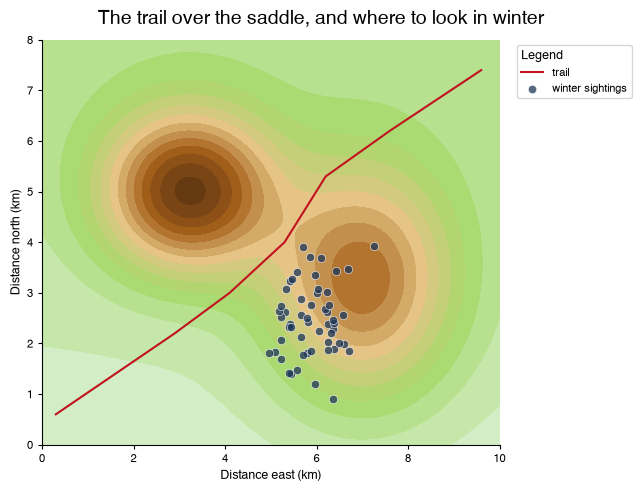

In [25]:
from datachart.charts import LineChart, ScatterChart
from datachart.utils import Panel

Panel(
    [
        # the terrain at the bottom
        {
            "figure": ContourChart(
                data=terrain,
                filled=True,
                levels=list(range(300, 1900, 100)),
                style={"plot_contour_cmap": TERRAIN_COLORS},
            ),
            "z_order": 1,
        },
        # the trail and the sightings on top, on the map's own axis
        {
            "figure": LineChart(data=trail, subtitle="trail", style={"plot_line_color": "#c1121f"}),
            "y_axis": "left",
            "z_order": 2,
        },
        {
            "figure": ScatterChart(
                data=sightings["Winter"],
                subtitle="winter sightings",
                style={"plot_scatter_color": "#1d3557"},
            ),
            "y_axis": "left",
            "z_order": 3,
        },
    ],
    title="The trail over the saddle, and where to look in winter",
    xlabel="Distance east (km)",
    ylabel_left="Distance north (km)",
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

[Grid](../../../references/utils/#datachart.utils.Grid) puts figures side by side instead, each in its own coordinate space. The labeled map sits next to the density of all sightings, so the reader can match the herd's favorite places to the landmarks. The [Grid](../../utility/grid/) guide covers layouts.

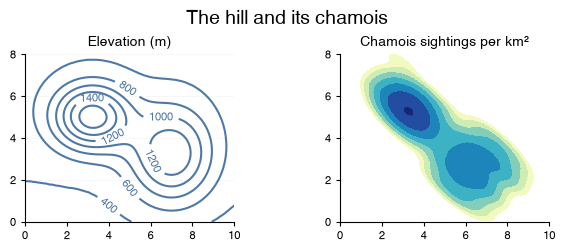

In [26]:
from datachart.utils import Grid

Grid(
    [
        [
            ContourChart(
                data=terrain,
                levels=[400, 600, 800, 1000, 1200, 1400, 1600],
                show_labels=True,
                valfmt="{x:.0f}",
                title="Elevation (m)",
                aspect_ratio=ASPECT_RATIO.EQUAL,
            ),
            ContourChart(
                data=sighting_density,
                filled=True,
                levels=[0.5, 1, 2, 4, 8, 16, 32, 64],
                norm=NORMALIZE.LOG,
                style={"plot_contour_cmap": COLORS.YlGnBu},
                title="Chamois sightings per km²",
                aspect_ratio=ASPECT_RATIO.EQUAL,
            ),
        ]
    ],
    title="The hill and its chamois",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

## Additional Features

### Density of scattered points

A contour of a density is the two-dimensional counterpart of a histogram: it shows where scattered points concentrate, without the overplotting of a crowded scatter chart. [datachart.utils.stats.kde2d](../../../references/utils/stats/#datachart.utils.stats.kde2d) estimates the density with a Gaussian kernel and returns the `{x, y, z}` surface that `ContourChart` takes, so `ContourChart(data=kde2d(x, y))` is a density chart. Its options:

- `bandwidth` sets how smooth the estimate is: a [BANDWIDTH](../../../references/constants/#datachart.constants.BANDWIDTH) rule (Scott's by default, or Silverman's) or a number that replaces the rule's factor, where smaller values follow the points more closely.
- `gridsize` sets the resolution of the surface.
- `cut` extends the grid past the points by that many bandwidths, so the outer contours close instead of being clipped; `xlim` and `ylim` fix the grid instead, so several surfaces share one (as `season_density` does).

The result is a probability density (it integrates to 1); multiplied by the number of points, it reads as points per unit area. The autumn sightings come from two groups: Scott's rule shows both, while a wide bandwidth (`2.0`) smooths them into one blob, the classic way a density estimate hides structure.

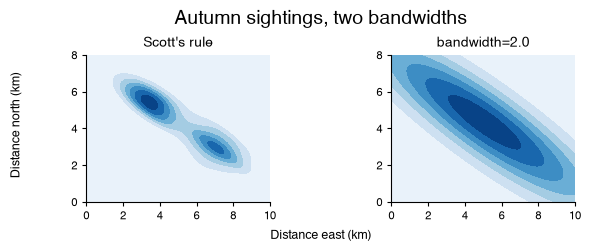

In [27]:
from datachart.constants import BANDWIDTH
from datachart.utils.stats import kde2d

autumn_east = [p["x"] for p in sightings["Autumn"]]
autumn_north = [p["y"] for p in sightings["Autumn"]]

Grid(
    [
        [
            ContourChart(
                # Scott's rule: two groups
                data=kde2d(autumn_east, autumn_north, bandwidth=BANDWIDTH.SCOTT, xlim=(0, 10), ylim=(0, 8)),
                filled=True,
                title="Scott's rule",
                aspect_ratio=ASPECT_RATIO.EQUAL,
            ),
            ContourChart(
                # a wide kernel: one blob, on the same map extent
                data=kde2d(autumn_east, autumn_north, bandwidth=2.0, xlim=(0, 10), ylim=(0, 8)),
                filled=True,
                title="bandwidth=2.0",
                aspect_ratio=ASPECT_RATIO.EQUAL,
            ),
        ]
    ],
    title="Autumn sightings, two bandwidths",
    xlabel="Distance east (km)",
    ylabel="Distance north (km)",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

### Axis scales

Some surfaces are sampled over values that span orders of magnitude, and a linear axis crams the interesting part into a corner. `scalex` and `scaley` take a [SCALE](../../../references/constants/#datachart.constants.SCALE) member. `sweep`, defined in a hidden cell, holds the illustrative validation loss of a model trained over a grid of learning rates (1e-5 to 1e-1) and weight decays (1e-6 to 1e-1), both sampled evenly on a log scale, the way hyperparameter searches are. On log axes the valley of good settings is a clear oval; on linear axes it would be squeezed against the left and bottom edges.

In [28]:
# illustrative validation loss over a log-spaced grid of learning rates and weight decays
LEARNING_RATES = np.logspace(-5, -1, 41)
WEIGHT_DECAYS = np.logspace(-6, -1, 51)
LR, WD = np.meshgrid(np.log10(LEARNING_RATES), np.log10(WEIGHT_DECAYS))
LOSS = 0.32 + 0.09 * (LR + 3) ** 2 + 0.03 * (WD + 3.5) ** 2 + 0.03 * (LR + 3) * (WD + 3.5)
sweep = {"x": LEARNING_RATES.tolist(), "y": WEIGHT_DECAYS.tolist(), "z": LOSS.tolist()}

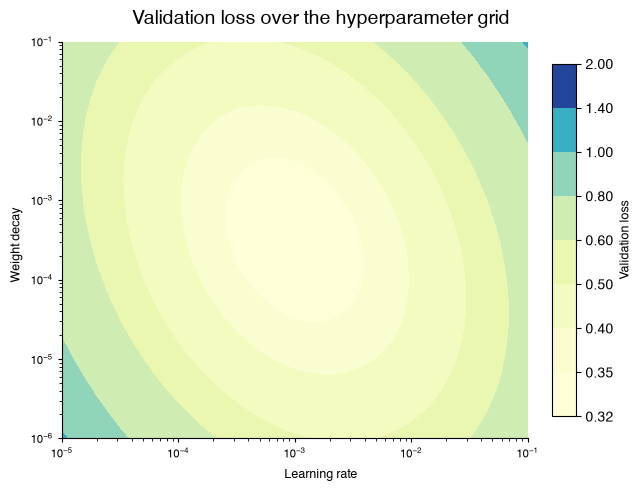

In [29]:
from datachart.constants import SCALE

ContourChart(
    data=sweep,
    # both hyperparameters on a log scale
    scalex=SCALE.LOG,
    scaley=SCALE.LOG,
    filled=True,
    show_colorbars=True,
    colorbar={"label": "Validation loss"},
    levels=[0.32, 0.35, 0.4, 0.5, 0.6, 0.8, 1.0, 1.4, 2.0],
    style={"plot_contour_cmap": COLORS.YlGnBu},
    title="Validation loss over the hyperparameter grid",
    xlabel="Learning rate",
    ylabel="Weight decay",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Datetime axis

A surface sampled over time, such as a measurement by date and depth or by date and elevation, belongs on a time axis. The `x` values may be real temporal objects (`datetime`, `date`, `numpy.datetime64` or a pandas `Timestamp`); they are placed at their elapsed time and the ticks pick readable labels for the span, while date strings are not parsed. `xticks_format` takes a [DATE_FORMAT](../../../references/constants/#datachart.constants.DATE_FORMAT) member or any `strftime` pattern, and `xticks`, `xmin`, `xmax`, reference lines and bands take datetimes as well. `snow`, defined in a hidden cell, holds the illustrative snow depth on the hill over one winter, by day and elevation: the snow line comes down through December and January, the pack is deepest in mid-February, and the lower slopes melt out first.

In [30]:
from datetime import date, timedelta

# illustrative snow depth in cm by day and elevation, over one winter
DAYS = [date(2024, 11, 1) + timedelta(days=i) for i in range(181)]
ELEVATIONS = list(range(400, 1801, 25))
# the snow line falls from 1500 m to 500 m by mid-February, then climbs 16 m a day
SNOW_LINE = [1000 + 500 * np.cos(np.pi * day / 106) if day <= 106 else 500 + 16 * (day - 106) for day in range(len(DAYS))]
DEPTH = [[max(0.0, (elevation - line) * 0.12) for line in SNOW_LINE] for elevation in ELEVATIONS]
snow = {"x": DAYS, "y": ELEVATIONS, "z": DEPTH}

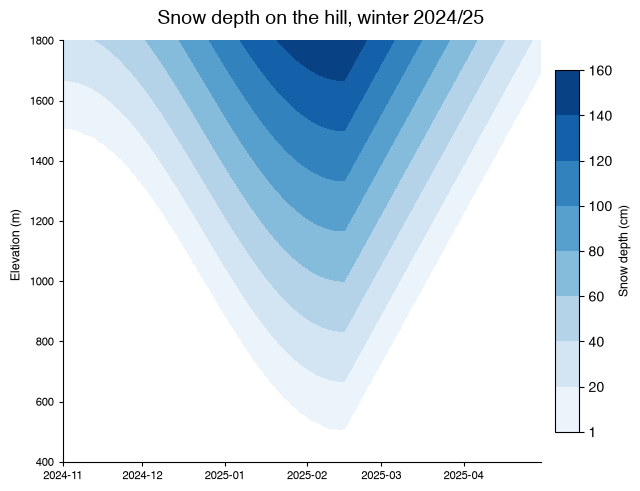

In [31]:
from datachart.constants import DATE_FORMAT

ContourChart(
    # dates on the x-axis
    data=snow,
    filled=True,
    show_colorbars=True,
    colorbar={"label": "Snow depth (cm)"},
    levels=[1, 20, 40, 60, 80, 100, 120, 140, 160],
    style={"plot_contour_cmap": COLORS.Blues},
    # the month of each tick
    xticks_format=DATE_FORMAT.YEAR_MONTH,
    title="Snow depth on the hill, winter 2024/25",
    ylabel="Elevation (m)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Real-World Examples

The examples below put the features above to work, each one answering a question. The data lives in hidden cells; each example says what its data is and where it comes from.

### Example 1: Why Does Gradient Descent Crawl? (Log Surface, Level Rule, Labels, and a Panel)

The [Rosenbrock function](https://en.wikipedia.org/wiki/Rosenbrock_function), `(1 - x)² + 100 (y - x²)²`, is the standard test surface for optimizers: a long, curved, flat-bottomed valley with the minimum at (1, 1), which gradient methods reach quickly but follow slowly. `rosenbrock` samples it on the square from -2 to 2 in x and -1 to 3 in y. Its values span six orders of magnitude, so the surface is drawn as `log(1 + z)`, which keeps the valley floor visible. `descent` traces 2000 steps of plain gradient descent (step size 0.001) from (-1.5, 2.5), computed in the hidden cell, with every 40th step kept. The Freedman-Diaconis rule cuts the surface densely enough for the narrow valley to get its own lines, and a `Panel` draws the path over the labeled iso-lines: the path drops into the valley within a few steps, then crawls along its floor towards the minimum.

In [32]:
ROSEN_X = np.linspace(-2, 2, 120)
ROSEN_Y = np.linspace(-1, 3, 120)
RX, RY = np.meshgrid(ROSEN_X, ROSEN_Y)
rosenbrock = {
    "x": ROSEN_X.tolist(),
    "y": ROSEN_Y.tolist(),
    "z": np.log1p((1 - RX) ** 2 + 100 * (RY - RX**2) ** 2).tolist(),
}

# plain gradient descent on the Rosenbrock function
point = np.array([-1.5, 2.5])
descent = [{"x": float(point[0]), "y": float(point[1])}]
for step in range(1, 2001):
    x, y = point
    gradient = np.array([-2 * (1 - x) - 400 * x * (y - x**2), 200 * (y - x**2)])
    point = point - 0.001 * gradient
    if step % 40 == 0:
        descent.append({"x": float(point[0]), "y": float(point[1])})

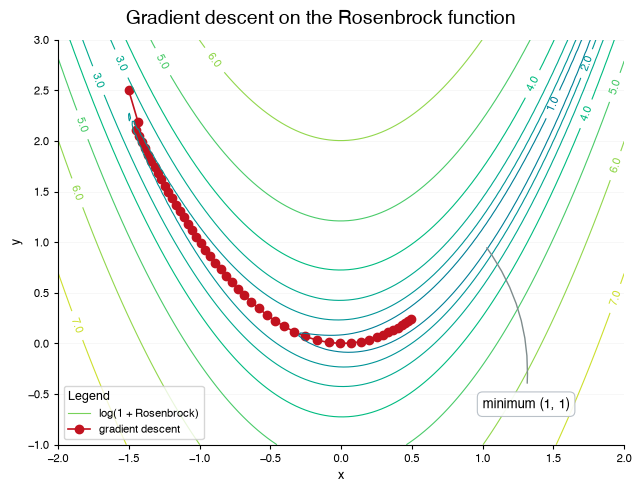

In [33]:
from datachart.constants import LINE_MARKER, VALUE_FORMAT

Panel(
    [
        ContourChart(
            data=rosenbrock,
            subtitle="log(1 + Rosenbrock)",
            # dense levels, so the narrow valley gets its own lines
            levels=CONTOUR_LEVELS.FD,
            show_labels=True,
            valfmt=VALUE_FORMAT.DECIMAL,
            style={"plot_contour_cmap": COLORS.Viridis, "plot_contour_line_width": 0.8},
            # point at the minimum
            texts={"text": "minimum (1, 1)", "x": 1.0, "y": -0.6, "target": (1, 1)},
        ),
        {
            "figure": LineChart(
                data=descent,
                subtitle="gradient descent",
                style={"plot_line_color": "#c1121f", "plot_line_marker": LINE_MARKER.CIRCLE, "plot_line_width": 1.2},
            ),
            # the path shares the surface's axes
            "y_axis": "left",
        },
    ],
    title="Gradient descent on the Rosenbrock function",
    xlabel="x",
    ylabel_left="y",
    show_legend=True,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 2: How Cold Does the Wind Make It Feel? (Explicit Levels, Emphasis, Labels, and a Panel)

The wind chill index, used by Environment Canada and the US National Weather Service since 2001, gives the temperature that feels the same on exposed skin in calm air: `13.12 + 0.6215 T - 11.37 V^0.16 + 0.3965 T V^0.16`, for the air temperature `T` in °C (up to 10 °C) and the wind speed `V` in km/h (from 5 km/h). `wind_chill` evaluates the formula on a grid of temperatures from -40 °C to 10 °C and wind speeds from 5 to 80 km/h. Environment Canada ties the risk of frostbite to the index: the risk is high from -28, very high from -40 and severe from -48, when exposed skin can freeze within minutes. A `Panel` draws the index twice: faint iso-lines every 5 degrees as the background, and the three thresholds highlighted and labeled. A note reads one point off the chart: -20 °C in a 40 km/h wind feels like about -34 °C.

In [34]:
# the wind chill index (Environment Canada / US National Weather Service, 2001)
AIR = np.linspace(-40, 10, 101)
WIND = np.linspace(5, 80, 76)
T, V = np.meshgrid(AIR, WIND)
wind_chill = {
    "x": AIR.tolist(),
    "y": WIND.tolist(),
    "z": (13.12 + 0.6215 * T - 11.37 * V**0.16 + 0.3965 * T * V**0.16).tolist(),
}
FROSTBITE = [-48, -40, -28]  # severe, very high, and high risk

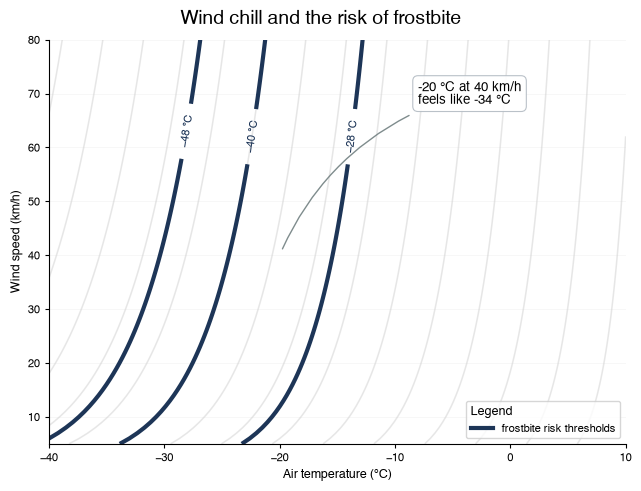

In [35]:
background = ContourChart(
    data=wind_chill,
    subtitle="wind chill, every 5 °C",
    levels=list(range(-65, 15, 5)),
    emphasis=EMPHASIS.BACKGROUND,
)
thresholds = ContourChart(
    data=wind_chill,
    subtitle="frostbite risk thresholds",
    # only the three thresholds, bold and labeled
    levels=FROSTBITE,
    emphasis=EMPHASIS.HIGHLIGHT,
    show_labels=True,
    valfmt="{x:.0f} °C",
    style={"plot_contour_color": "#1d3557"},
    texts={"text": "-20 °C at 40 km/h\nfeels like -34 °C", "x": -8, "y": 70, "target": (-20, 40)},
)

Panel(
    [background, thresholds],
    title="Wind chill and the risk of frostbite",
    xlabel="Air temperature (°C)",
    ylabel_left="Wind speed (km/h)",
    show_legend=True,
    legend={"location": LEGEND_LOCATION.LOWER_RIGHT},
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 3: Where Do the Penguin Species Overlap? (Densities over Points, Shared Levels, Panel and Grid)

The [Palmer penguins](https://allisonhorst.github.io/palmerpenguins/) dataset (Gorman, Williams and Fraser, 2014; CC0) records the flipper length and body mass of 342 penguins of three species on the Palmer Archipelago, Antarctica. `penguins` holds every penguin as a point (flipper length in mm, body mass in g), and `species_density` one density surface per species, estimated with `kde2d` on one shared grid (the range of all penguins, padded by 10%) and scaled to penguins per mm per kg. The question is which species these two measurements tell apart. The top row overlays two density outlines per species on the points with a `Panel`; the bottom row draws each species as a filled density with one shared `levels` list, so the same shade means the same density, in a `Grid`. Gentoo penguins stand apart, heavier and longer-flippered, while the Adelie and Chinstrap densities cover the same ground.

In [36]:
SPECIES = ["Adelie", "Chinstrap", "Gentoo"]

# (flipper length in mm, body mass in g) per penguin, by species
PENGUINS = {
    "Adelie": [
        (181, 3750), (186, 3800), (195, 3250), (193, 3450), (190, 3650), (181, 3625),
        (195, 4675), (193, 3475), (190, 4250), (186, 3300), (180, 3700), (182, 3200),
        (191, 3800), (198, 4400), (185, 3700), (195, 3450), (197, 4500), (184, 3325),
        (194, 4200), (174, 3400), (180, 3600), (189, 3800), (185, 3950), (180, 3800),
        (187, 3800), (183, 3550), (187, 3200), (172, 3150), (180, 3950), (178, 3250),
        (178, 3900), (188, 3300), (184, 3900), (195, 3325), (196, 4150), (190, 3950),
        (180, 3550), (181, 3300), (184, 4650), (182, 3150), (195, 3900), (186, 3100),
        (196, 4400), (185, 3000), (190, 4600), (182, 3425), (179, 2975), (190, 3450),
        (191, 4150), (186, 3500), (188, 4300), (190, 3450), (200, 4050), (187, 2900),
        (191, 3700), (186, 3550), (193, 3800), (181, 2850), (194, 3750), (185, 3150),
        (195, 4400), (185, 3600), (192, 4050), (184, 2850), (192, 3950), (195, 3350),
        (188, 4100), (190, 3050), (198, 4450), (190, 3600), (190, 3900), (196, 3550),
        (197, 4150), (190, 3700), (195, 4250), (191, 3700), (184, 3900), (187, 3550),
        (195, 4000), (189, 3200), (196, 4700), (187, 3800), (193, 4200), (191, 3350),
        (194, 3550), (190, 3800), (189, 3500), (189, 3950), (190, 3600), (202, 3550),
        (205, 4300), (185, 3400), (186, 4450), (187, 3300), (208, 4300), (190, 3700),
        (196, 4350), (178, 2900), (192, 4100), (192, 3725), (203, 4725), (183, 3075),
        (190, 4250), (193, 2925), (184, 3550), (199, 3750), (190, 3900), (181, 3175),
        (197, 4775), (198, 3825), (191, 4600), (193, 3200), (197, 4275), (191, 3900),
        (196, 4075), (188, 2900), (199, 3775), (189, 3350), (189, 3325), (187, 3150),
        (198, 3500), (176, 3450), (202, 3875), (186, 3050), (199, 4000), (191, 3275),
        (195, 4300), (191, 3050), (210, 4000), (190, 3325), (197, 3500), (193, 3500),
        (199, 4475), (187, 3425), (190, 3900), (191, 3175), (200, 3975), (185, 3400),
        (193, 4250), (193, 3400), (187, 3475), (188, 3050), (190, 3725), (192, 3000),
        (185, 3650), (190, 4250), (184, 3475), (195, 3450), (193, 3750), (187, 3700),
        (201, 4000),
    ],
    "Chinstrap": [
        (192, 3500), (196, 3900), (193, 3650), (188, 3525), (197, 3725), (198, 3950),
        (178, 3250), (197, 3750), (195, 4150), (198, 3700), (193, 3800), (194, 3775),
        (185, 3700), (201, 4050), (190, 3575), (201, 4050), (197, 3300), (181, 3700),
        (190, 3450), (195, 4400), (181, 3600), (191, 3400), (187, 2900), (193, 3800),
        (195, 3300), (197, 4150), (200, 3400), (200, 3800), (191, 3700), (205, 4550),
        (187, 3200), (201, 4300), (187, 3350), (203, 4100), (195, 3600), (199, 3900),
        (195, 3850), (210, 4800), (192, 2700), (205, 4500), (210, 3950), (187, 3650),
        (196, 3550), (196, 3500), (196, 3675), (201, 4450), (190, 3400), (212, 4300),
        (187, 3250), (198, 3675), (199, 3325), (201, 3950), (193, 3600), (203, 4050),
        (187, 3350), (197, 3450), (191, 3250), (203, 4050), (202, 3800), (194, 3525),
        (206, 3950), (189, 3650), (195, 3650), (207, 4000), (202, 3400), (193, 3775),
        (210, 4100), (198, 3775),
    ],
    "Gentoo": [
        (211, 4500), (230, 5700), (210, 4450), (218, 5700), (215, 5400), (210, 4550),
        (211, 4800), (219, 5200), (209, 4400), (215, 5150), (214, 4650), (216, 5550),
        (214, 4650), (213, 5850), (210, 4200), (217, 5850), (210, 4150), (221, 6300),
        (209, 4800), (222, 5350), (218, 5700), (215, 5000), (213, 4400), (215, 5050),
        (215, 5000), (215, 5100), (216, 4100), (215, 5650), (210, 4600), (220, 5550),
        (222, 5250), (209, 4700), (207, 5050), (230, 6050), (220, 5150), (220, 5400),
        (213, 4950), (219, 5250), (208, 4350), (208, 5350), (208, 3950), (225, 5700),
        (210, 4300), (216, 4750), (222, 5550), (217, 4900), (210, 4200), (225, 5400),
        (213, 5100), (215, 5300), (210, 4850), (220, 5300), (210, 4400), (225, 5000),
        (217, 4900), (220, 5050), (208, 4300), (220, 5000), (208, 4450), (224, 5550),
        (208, 4200), (221, 5300), (214, 4400), (231, 5650), (219, 4700), (230, 5700),
        (214, 4650), (229, 5800), (220, 4700), (223, 5550), (216, 4750), (221, 5000),
        (221, 5100), (217, 5200), (216, 4700), (230, 5800), (209, 4600), (220, 6000),
        (215, 4750), (223, 5950), (212, 4625), (221, 5450), (212, 4725), (224, 5350),
        (212, 4750), (228, 5600), (218, 4600), (218, 5300), (212, 4875), (230, 5550),
        (218, 4950), (228, 5400), (212, 4750), (224, 5650), (214, 4850), (226, 5200),
        (216, 4925), (222, 4875), (203, 4625), (225, 5250), (219, 4850), (228, 5600),
        (215, 4975), (228, 5500), (216, 4725), (215, 5500), (210, 4700), (219, 5500),
        (208, 4575), (209, 5500), (216, 5000), (229, 5950), (213, 4650), (230, 5500),
        (217, 4375), (230, 5850), (217, 4875), (222, 6000), (214, 4925), (215, 4850),
        (222, 5750), (212, 5200), (213, 5400),
    ],
}

penguins = [{"x": flipper, "y": mass} for species in SPECIES for flipper, mass in PENGUINS[species]]


def padded(values, padding=0.1):
    low, high = min(values), max(values)
    return low - padding * (high - low), high + padding * (high - low)


FLIPPER_RANGE = padded([p["x"] for p in penguins])
MASS_RANGE = padded([p["y"] for p in penguins])
species_density = []
for species in SPECIES:
    flippers, masses = zip(*PENGUINS[species])
    surface = kde2d(list(flippers), list(masses), gridsize=80, xlim=FLIPPER_RANGE, ylim=MASS_RANGE)
    # penguins per mm of flipper length and kg of body mass
    surface["z"] = (np.array(surface["z"]) * len(flippers) * 1000).tolist()
    species_density.append(surface)

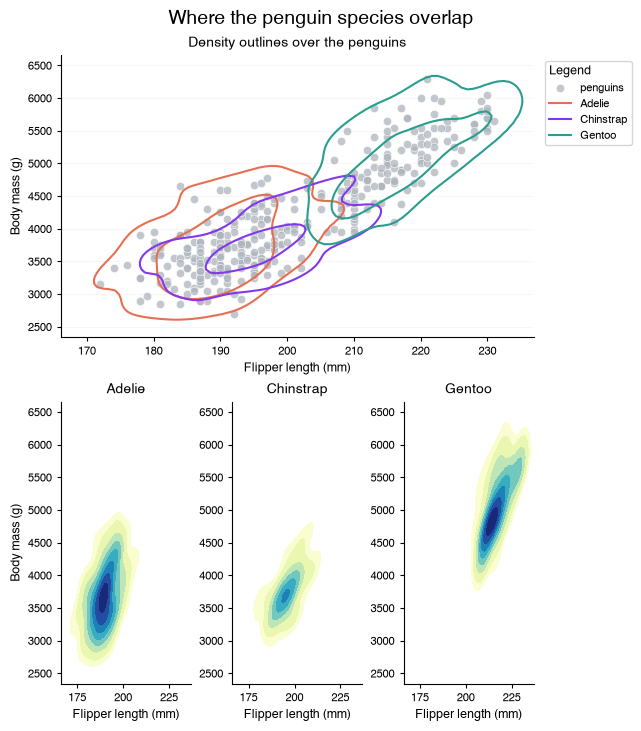

In [37]:
SPECIES_STYLE = [{"plot_contour_color": color} for color in ["#e76f51", "#8338ec", "#2a9d8f"]]
DENSITY_LEVELS = [0.5, 1, 2, 3, 4, 5, 6, 7, 8]

overlap = Panel(
    [
        ScatterChart(data=penguins, subtitle="penguins", style={"plot_scatter_color": "#adb5bd"}),
        {
            # an outer and an inner outline per species
            "figure": ContourChart(data=species_density, subtitle=SPECIES, style=SPECIES_STYLE, levels=[0.5, 3]),
            "y_axis": "left",
        },
    ],
    title="Density outlines over the penguins",
    xlabel="Flipper length (mm)",
    ylabel_left="Body mass (g)",
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_RIGHT},
)


def species_panel(index):
    # one species as a filled density, on the shared levels
    return ContourChart(
        data=species_density[index],
        filled=True,
        levels=DENSITY_LEVELS,
        style={"plot_contour_cmap": COLORS.YlGnBu},
        title=SPECIES[index],
        xlabel="Flipper length (mm)",
        ylabel="Body mass (g)" if index == 0 else None,
    )


Grid(
    [
        [overlap],
        [species_panel(0), species_panel(1), species_panel(2)],
    ],
    title="Where the penguin species overlap",
    figsize=FIG_SIZE.FULL_TALL,
).show()